In [21]:
import numpy as np

In [22]:
ip = np.load("/home/gokul/ideaslab/ai-research-forcePose-fork/data/data_2d_force_pose_pt_coco.npz", allow_pickle=True)

In [23]:
positions_2d = ip['positions_2d'].item()
subject1_squat07 = positions_2d['Subject7']['Single_Leg_Jump_R02']

In [16]:
positions_2d['Subject7'].keys()

dict_keys(['Counter_Movement_Jump02', 'Single_Leg_Jump_R02', 'Single_Leg_Jump_L01', 'Counter_Movement_Jump01', 'Single_Leg_Jump_R01', 'Jump_Squat01', 'Single_Leg_Squat_L03', 'Single_Leg_Jump_L02', 'Single_Leg_Squat_R', 'Single_Leg_Squat_R01', 'Single_Leg_Squat_L02', 'Single_Leg_Jump_L03', 'Squat', 'Squat02', 'Jump_Squat02', 'Squat01', 'Jump_Squat03', 'Single_Leg_Jump_R03', 'Single_Leg_Squat_R02', 'Single_Leg_Squat_L01', 'Counter_Movement_Jump03'])

In [ ]:
subject1_squat07

In [32]:
arr = np.array(subject1_squat07[0])

np.save("out_files/orig_data.npy", arr)

In [17]:
pred = np.load("out_files/grf_pred_yolo.npz")

forces = pred['pred_grf']

In [18]:
# np.save("out_files/skeleton.npy", subject1_squat07)
# np.save("out_files/pred_force.npy", pred["pred_grf"])

In [19]:
forces.min(), forces.max()

(np.float32(0.00071967393), np.float32(3.2024064))

In [4]:
Fz_L = forces[:, 1]
Fz_R = forces[:, 4]

In [10]:
forces[:10]

array([[0.05357229, 2.81149   , 0.07595799, 0.04483303, 0.91556305,
        0.03876733],
       [0.05342599, 2.8104987 , 0.07581609, 0.04509987, 0.91713744,
        0.03867822],
       [0.05355703, 2.8114066 , 0.07605573, 0.0450501 , 0.9174935 ,
        0.03879348],
       [0.05343658, 2.8105721 , 0.07601485, 0.045057  , 0.9175512 ,
        0.0387066 ],
       [0.05362169, 2.8103852 , 0.07606141, 0.04510861, 0.9177564 ,
        0.03880017],
       [0.05340528, 2.8110178 , 0.07618949, 0.04514611, 0.918494  ,
        0.03878813],
       [0.05349704, 2.810867  , 0.07603904, 0.04514194, 0.91871375,
        0.03859511],
       [0.05357805, 2.8109617 , 0.07628869, 0.04495765, 0.91826123,
        0.03878743],
       [0.05328729, 2.8119752 , 0.07617508, 0.04516333, 0.91919523,
        0.03884866],
       [0.05329547, 2.8120239 , 0.07608685, 0.04508856, 0.9186812 ,
        0.03873754]], dtype=float32)

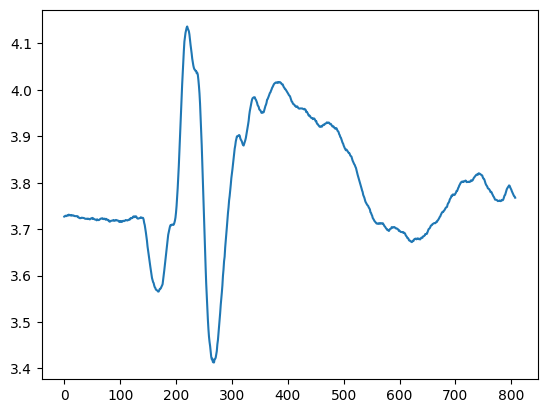

In [5]:
import matplotlib.pyplot as plt

plt.plot(Fz_L + Fz_R)

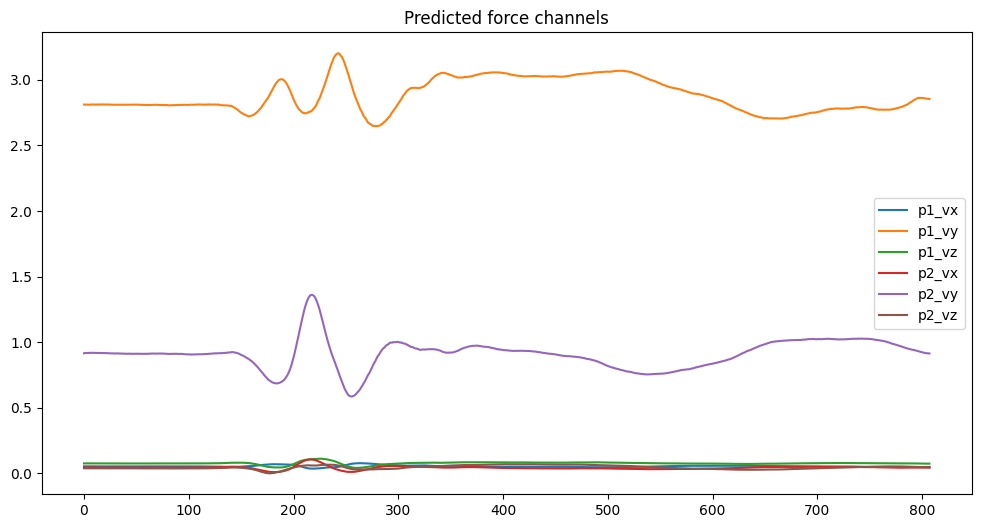

In [6]:
labels = ["p1_vx", "p1_vy", "p1_vz", "p2_vx", "p2_vy", "p2_vz"]

plt.figure(figsize=(12, 6))
for i in range(6):
    plt.plot(forces[:, i], label=labels[i])

plt.legend()
plt.title("Predicted force channels")
plt.show()